# Práctica 5

In [2]:
# Importando librearias necesarias:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Operator
from qiskit.circuit.library import UnitaryGate
from qiskit.visualization import plot_histogram
from qiskit.providers.basic_provider import BasicSimulator
import numpy as np

## Ejercicio 1 : "Determina el valor de la cadena oculta s"

Ejecutamos la siguiente línea para definir bv_oracle()

In [3]:
exec(bytes.fromhex('0a66726f6d207169736b697420696d706f7274205175616e74756d436972637569740a0a6465662062765f6f7261636c6528293a0a2020202073203d20223131303130220a202020206e203d206c656e2873290a2020202073203d20735b3a3a2d315d202320726576657274696d6f73206c6120636164656e612079612071756520735f3020657374c3a12061206c6120697a7175696572646120736567c3ba6e20507974686f6e2c7920656e206c61206465726563686120736567c3ba6e205169736b69740a0a2020202063697263756974203d205175616e74756d43697263756974286e202b2031290a20202020636972637569742e6261727269657228290a0a20202020666f72206920696e2072616e6765286e293a0a2020202020202020696620735b695d203d3d202731273a0a202020202020202020202020636972637569742e63782869202b20312c2030290a0a20202020636972637569742e6261727269657228290a2020202072657475726e20636972637569740a20202020'))

In [14]:
oraculo = bv_oracle()
op = Operator(oraculo)
matrix = op
Uf_Oracle = UnitaryGate(matrix, 'TheOracle') #Compuerta personalizada

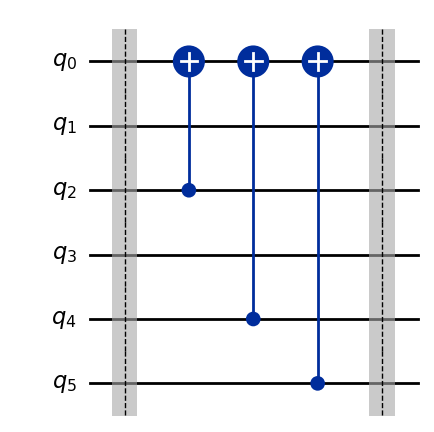

In [15]:
oraculo.draw('mpl')

### Implementa todo el algoritmo de Bernstein–Vazirani para determinar la cadena s

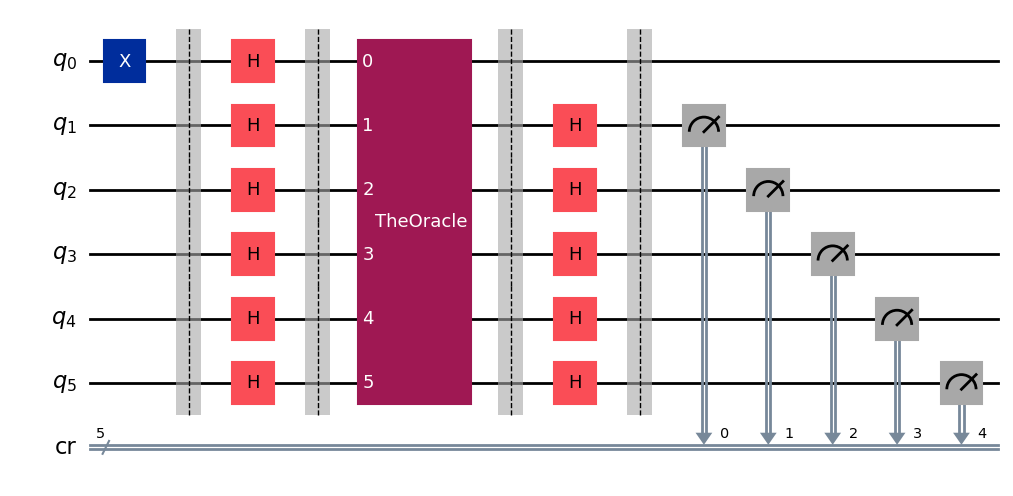

In [33]:
qc = QuantumRegister(6, name='q')# circuito con 6 qubits 
cr = ClassicalRegister(5, name='cr')         #5 bit clásicos

BVCircuit = QuantumCircuit(qc, cr)

BVCircuit.x(0)

BVCircuit.barrier()

BVCircuit.h(0)
BVCircuit.h(1)
BVCircuit.h(2)
BVCircuit.h(3)
BVCircuit.h(4)
BVCircuit.h(5)

BVCircuit.barrier()

BVCircuit.compose(Uf_Oracle, inplace=True)

BVCircuit.barrier()


BVCircuit.h(1)
BVCircuit.h(2)
BVCircuit.h(3)
BVCircuit.h(4)
BVCircuit.h(5)

BVCircuit.barrier()

BVCircuit.measure([1,2,3,4,5],[0,1,2,3,4])


BVCircuit.draw('mpl')



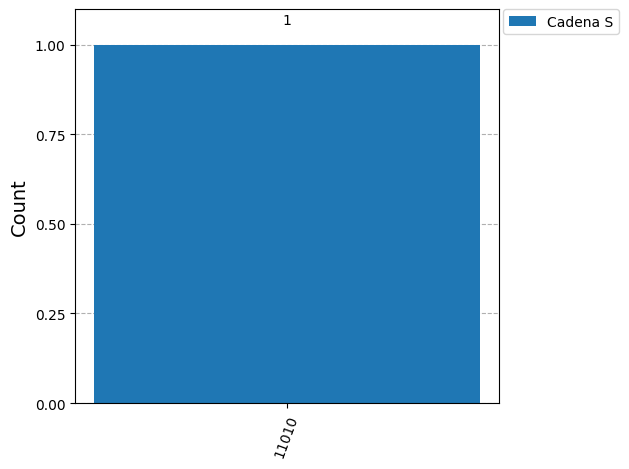

In [35]:
sim_basic = BasicSimulator()                       # usamos el simulador básico

# ejecutar el circuito, una sola vez es suficiente
job_sampler = sim_basic.run(BVCircuit, shots=1)

conteos = job_sampler.result().get_counts()        # obtener los conteos

legend = ["Cadena S"]
plot_histogram([conteos], legend=legend)

La cadena "s" es **S = 11010**

## Ejercicio 2